In [12]:
from utility import load_test_results, architecture_stats, sample_image

from NeuralNetwork import NeuralNetwork, torch

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.min_rows', 5000)
pd.set_option('display.max_rows', 5000)

In [13]:
classifiers_dict, all_results = load_test_results("Classifier_3")

In [14]:
classifiers_dict

{0: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2'])"}

In [15]:
all_results.head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
0,0,0,0.6,['Conv2'],0.0005,32,5,0.00,0.981735,0.080683,30.840531
1,1,0,0.6,['Conv2'],0.0005,32,5,0.25,0.972253,0.091232,7.001711
2,2,0,0.6,['Conv2'],0.0005,32,5,0.50,0.987591,0.080886,14.667440
3,3,0,0.6,['Conv2'],0.0005,32,5,0.75,0.995259,0.080821,10.189537
4,4,0,0.6,['Conv2'],0.0005,32,10,0.00,0.994283,0.081447,30.537555
5,5,0,0.6,['Conv2'],0.0005,32,10,0.25,0.994980,0.081631,42.559637
6,6,0,0.6,['Conv2'],0.0005,32,10,0.50,0.987451,0.082619,55.975638
7,7,0,0.6,['Conv2'],0.0005,32,10,0.75,0.993028,0.081127,26.303567


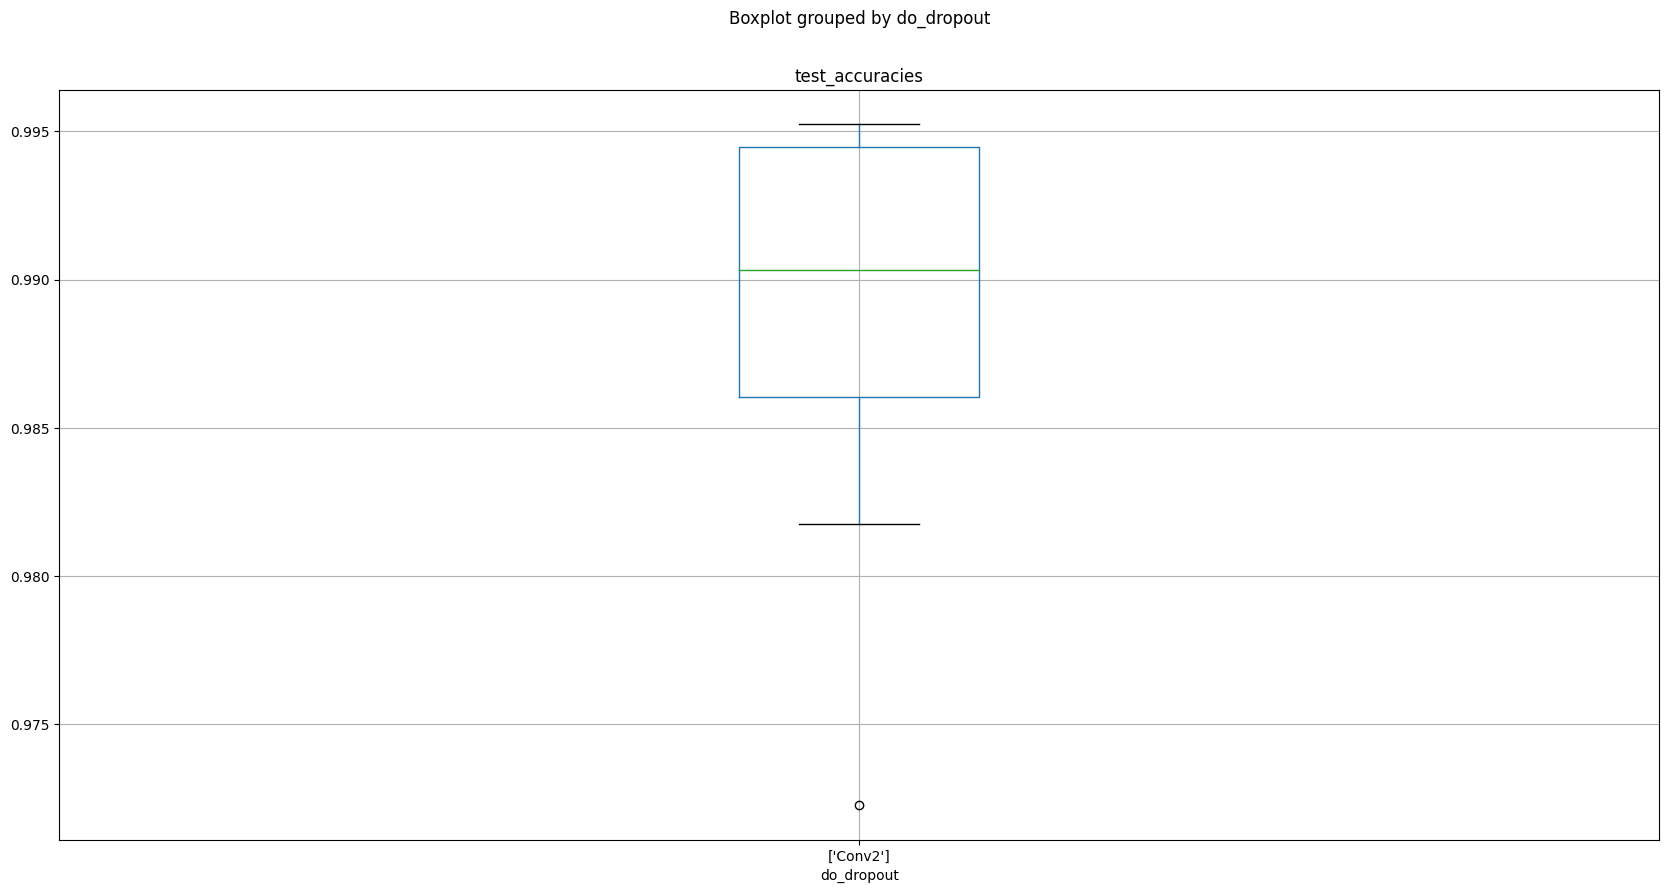

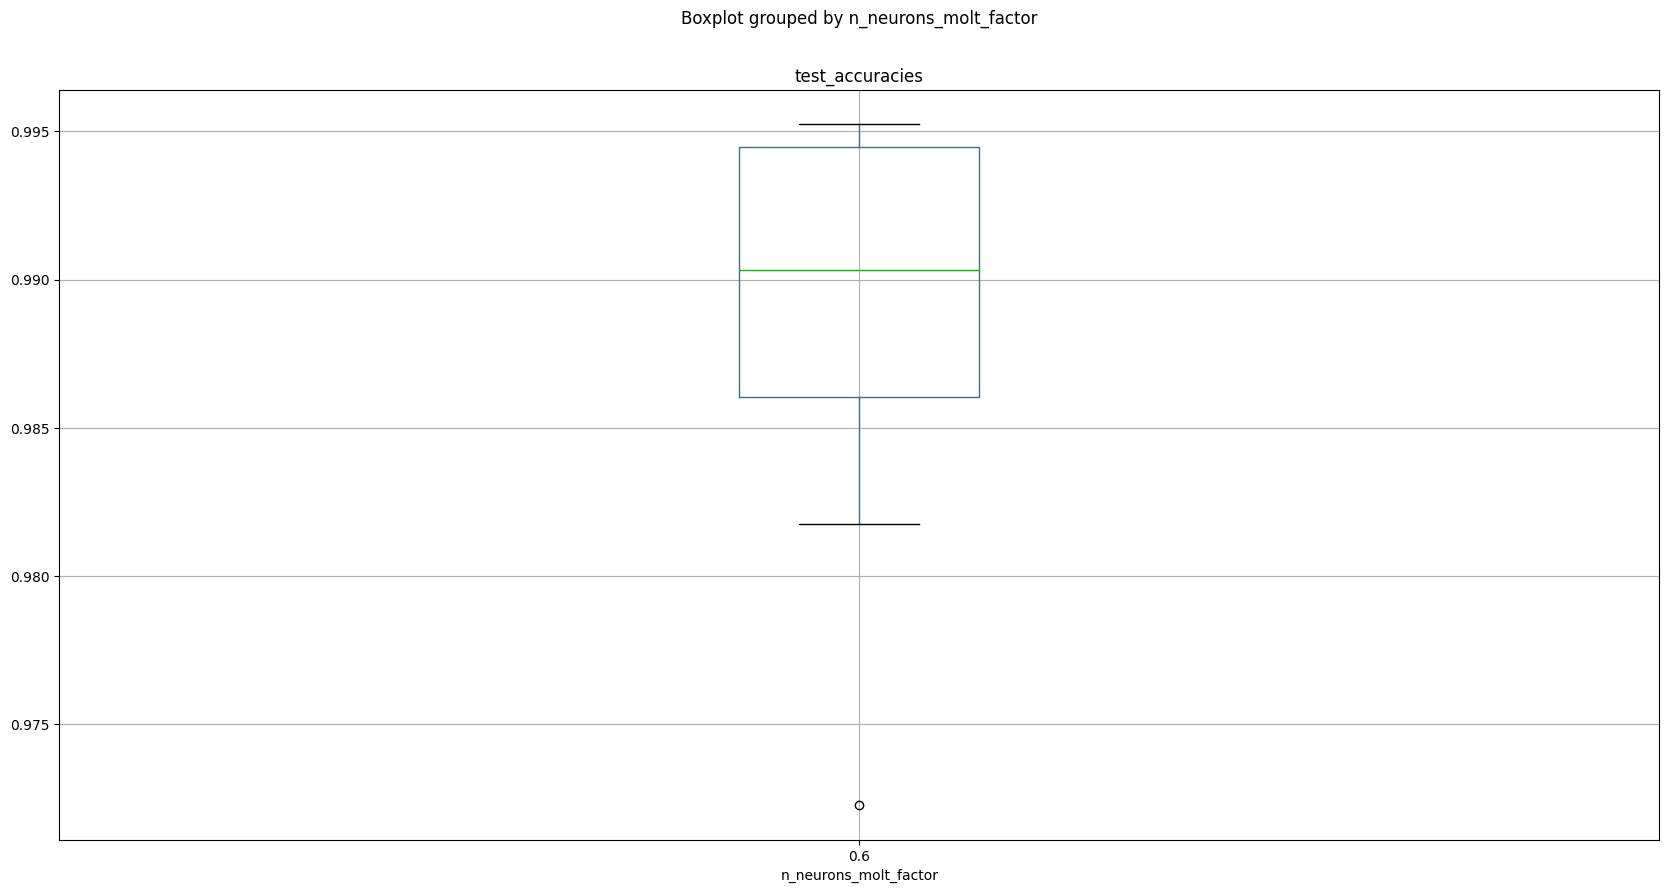

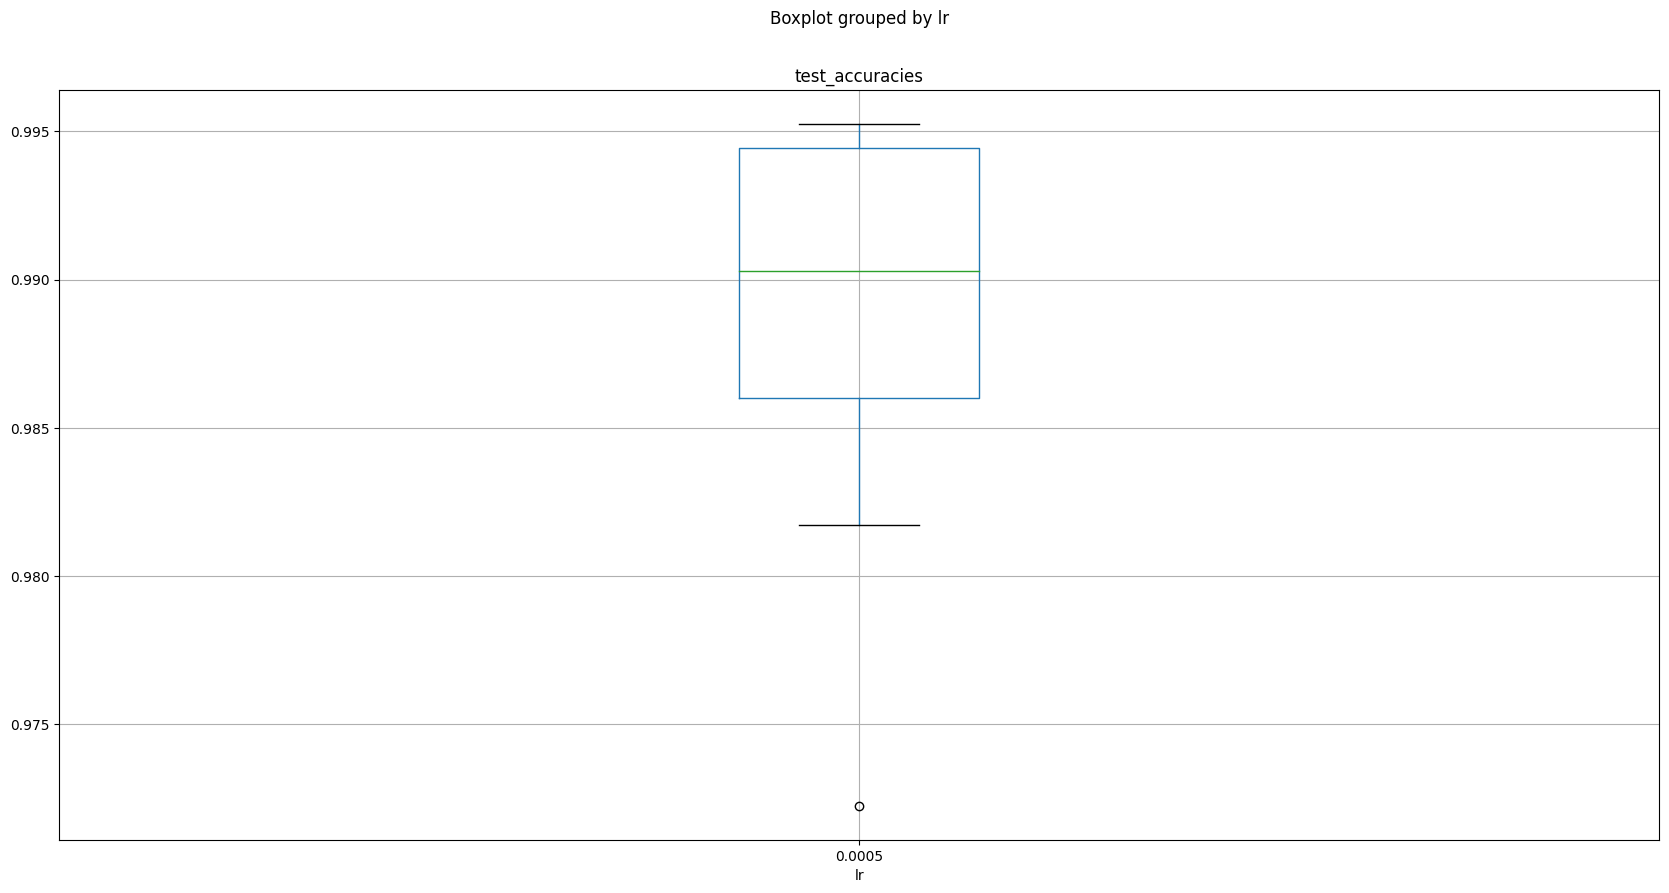

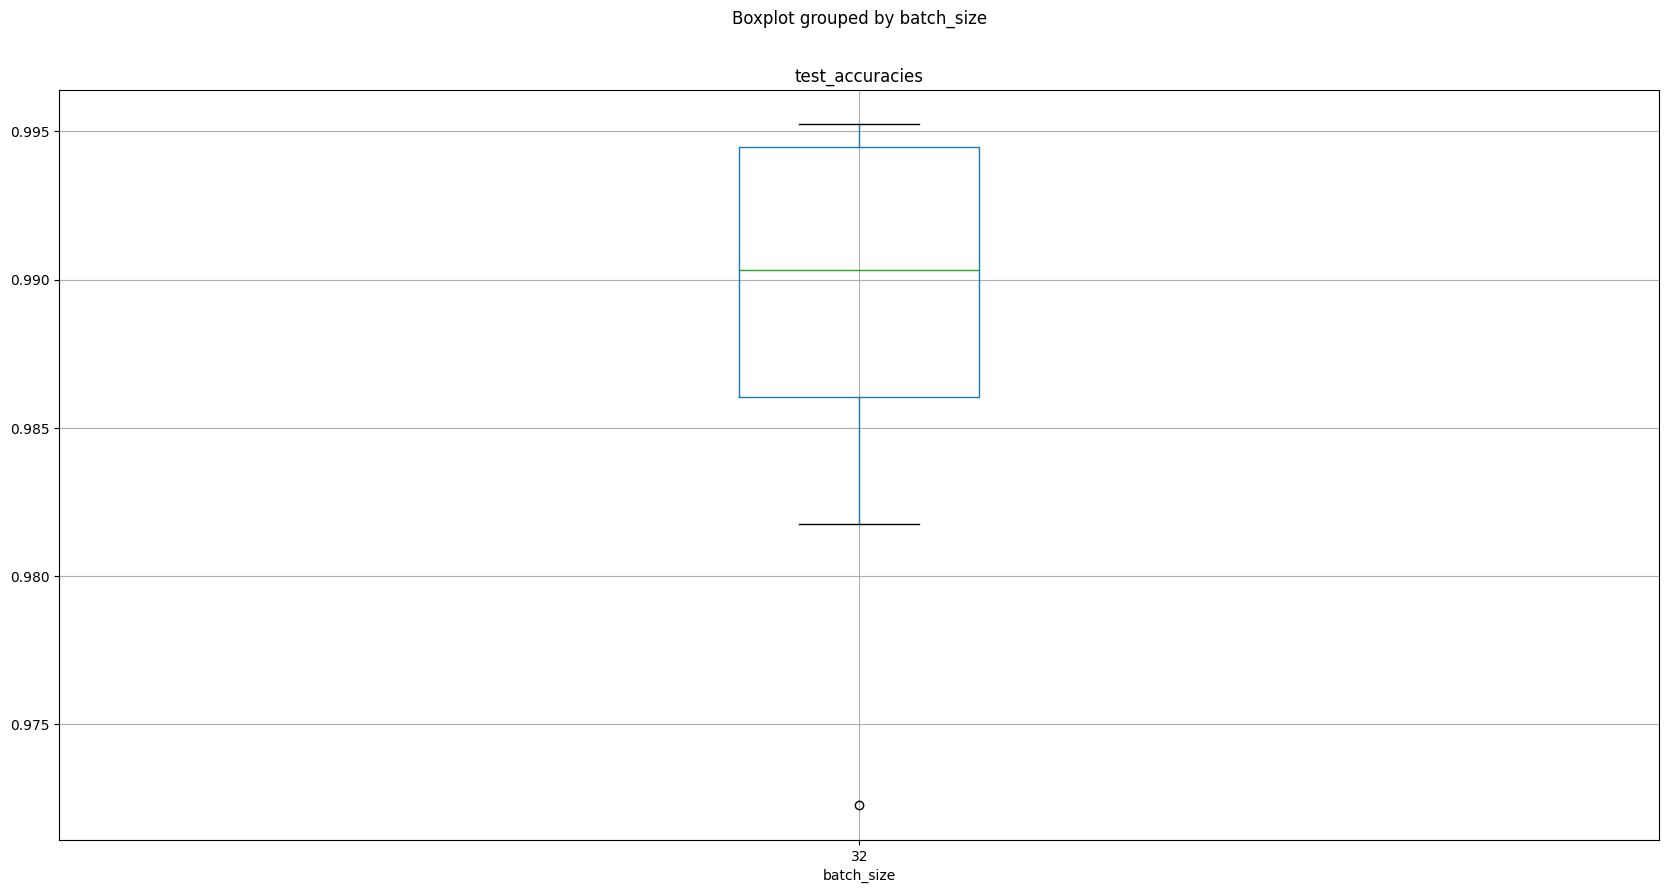

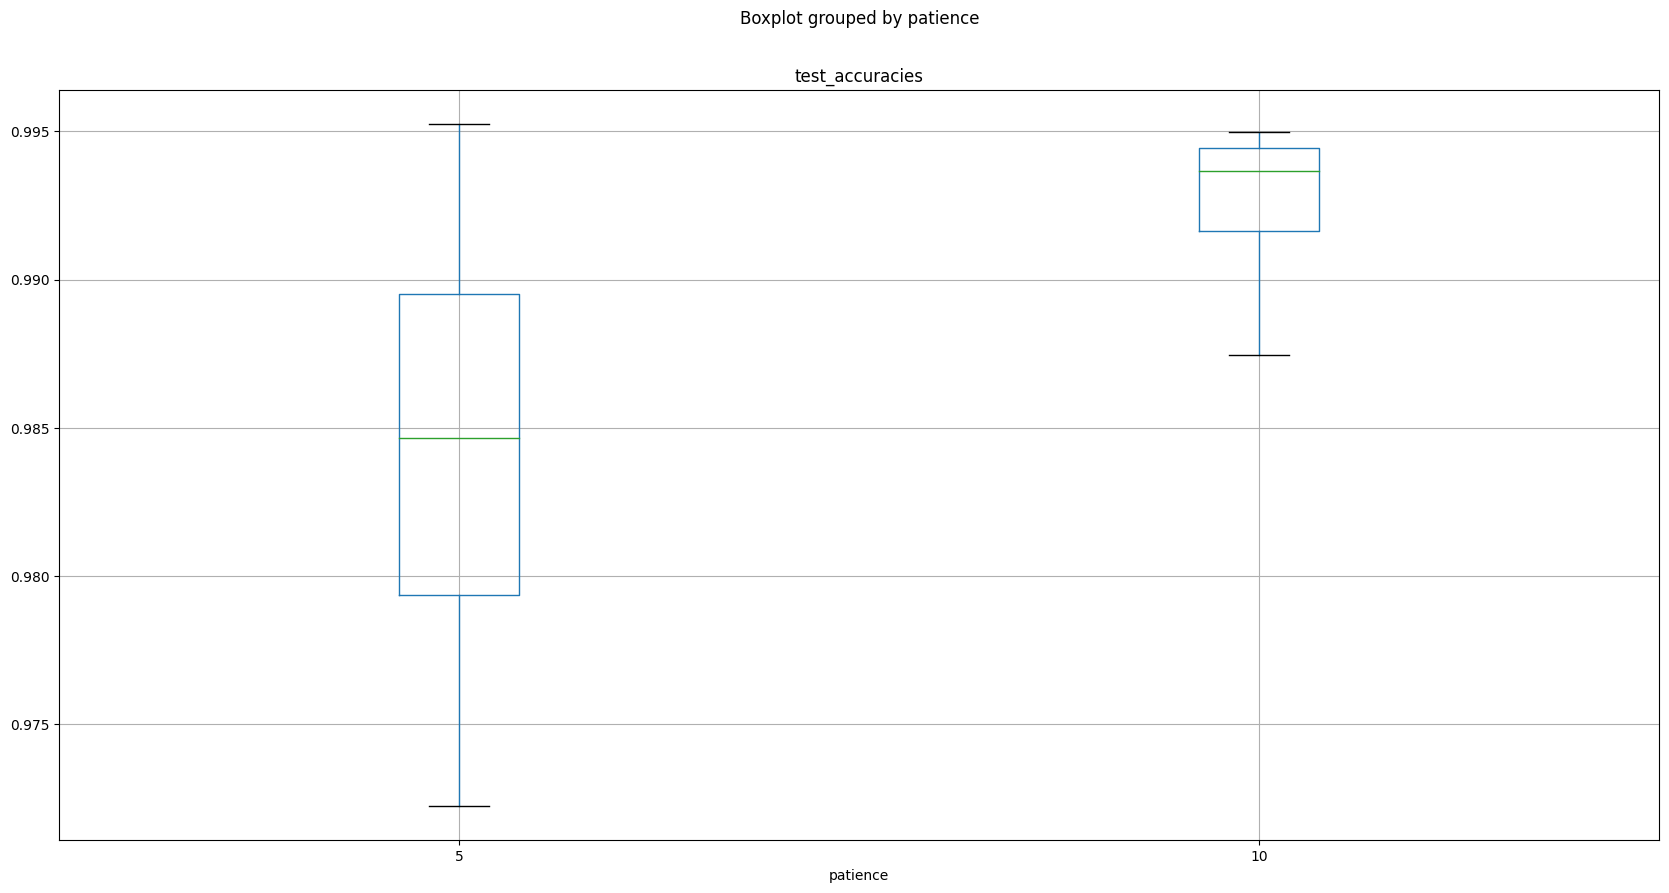

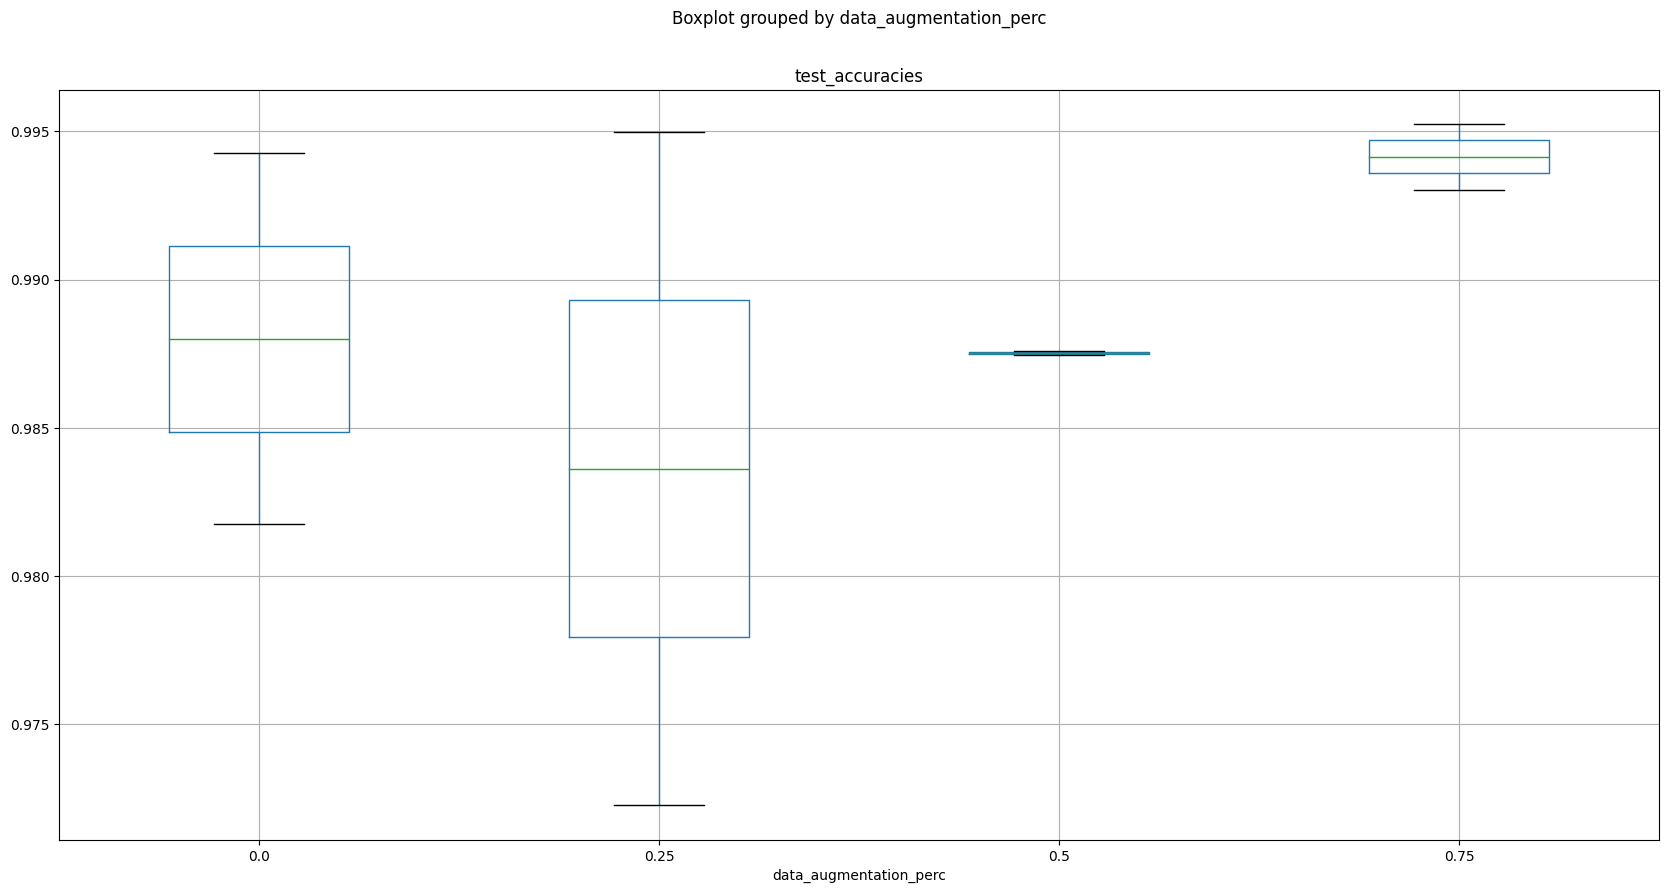

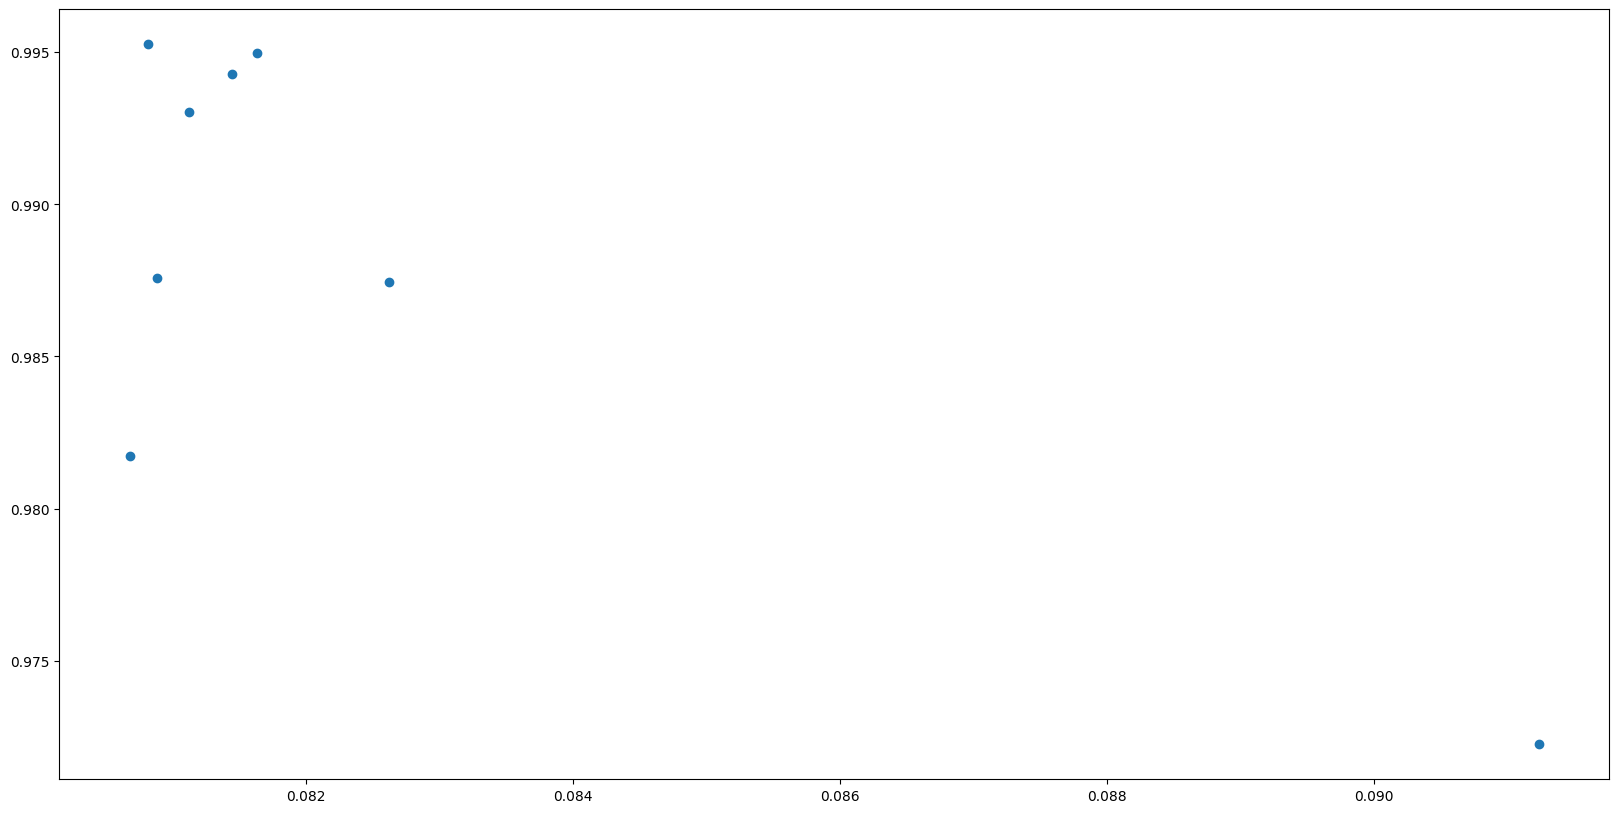

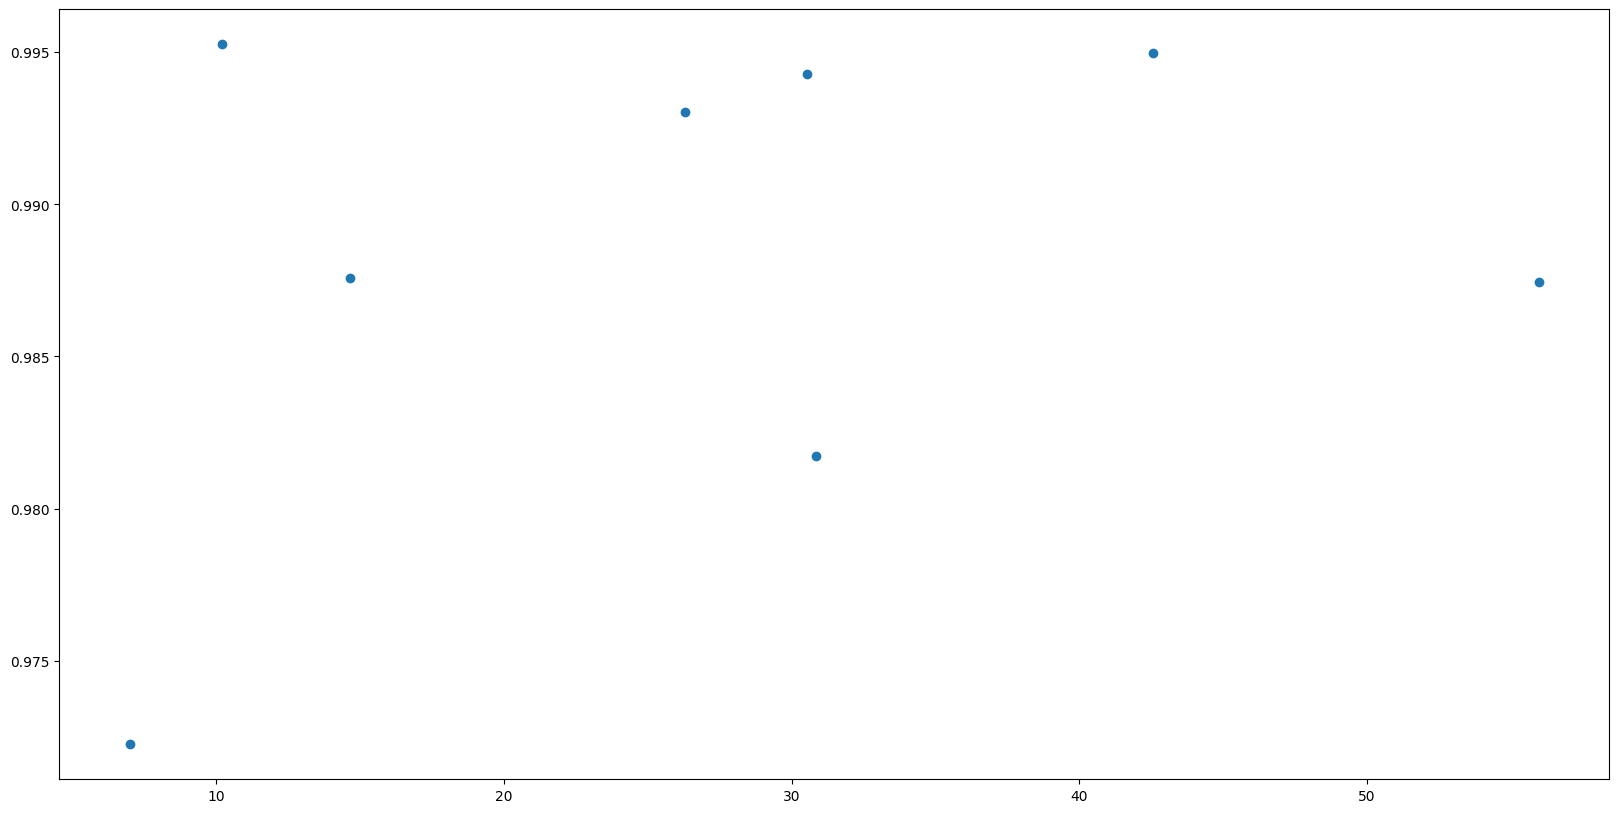

In [16]:
def plot_hyper():
    
    fig,ax=plt.subplots(figsize=(20,10))
    prova = all_results.sort_values(by="do_dropout")
    prova.boxplot(column =["test_accuracies"], by="do_dropout", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="n_neurons_molt_factor", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="lr", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="batch_size", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="patience", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="data_augmentation_perc", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    ax.scatter(all_results["test_times"], all_results["test_accuracies"])
    
    fig,ax=plt.subplots(figsize=(20,10))
    ax.scatter(all_results["train_times"], all_results["test_accuracies"])

plot_hyper()

In [17]:
all_results.sort_values(by=['test_accuracies'], ascending=False).head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
3,3,0,0.6,['Conv2'],0.0005,32,5,0.75,0.995259,0.080821,10.189537
5,5,0,0.6,['Conv2'],0.0005,32,10,0.25,0.994980,0.081631,42.559637
4,4,0,0.6,['Conv2'],0.0005,32,10,0.00,0.994283,0.081447,30.537555
7,7,0,0.6,['Conv2'],0.0005,32,10,0.75,0.993028,0.081127,26.303567
2,2,0,0.6,['Conv2'],0.0005,32,5,0.50,0.987591,0.080886,14.667440
6,6,0,0.6,['Conv2'],0.0005,32,10,0.50,0.987451,0.082619,55.975638
0,0,0,0.6,['Conv2'],0.0005,32,5,0.00,0.981735,0.080683,30.840531
1,1,0,0.6,['Conv2'],0.0005,32,5,0.25,0.972253,0.091232,7.001711


In [18]:
n_high_accuracy_architectures = len(all_results[all_results["test_accuracies"]==all_results["test_accuracies"].max()])
n_high_accuracy_architectures

1

In [19]:
high_accuracy_architectures = all_results.sort_values(by=['test_accuracies'], ascending=False).head(n_high_accuracy_architectures)["architecture_id"].unique()
high_accuracy_architectures

array([0])

In [20]:
for model in high_accuracy_architectures:
    architecture_stats(all_results, classifiers_dict, model)

Stats for architecture: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2']) (id: 0)
mean accuracy: 0.9883 with standard error: 0.0080

worst accuracy: 0.9723 with hyperparameters:
test_id                          1
lr                          0.0005
batch_size                      32
patience                         5
data_augmentation_perc        0.25
test_times                0.091232
train_times               7.001711
Name: 1, dtype: object 

best accuracy: 0.9953 with hyperparameters:
test_id                           3
lr                           0.0005
batch_size                       32
patience                          5
data_augmentation_perc         0.75
test_times                 0.080821
train_times               10.189537
Name: 3, dtype: object 



Loaded model: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2'])_test_3


Architecture:
name: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2'])
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 32, 12, 12]          --
|    └─Conv2d: 2-1                       [-1, 32, 24, 24]          832
|    └─MaxPool2d: 2-2                    [-1, 32, 12, 12]          --
|    └─ReLU: 2-3                         [-1, 32, 12, 12]          --
├─Sequential: 1-2                        [-1, 64, 4, 4]            --
|    └─Conv2d: 2-4                       [-1, 64, 8, 8]            51,264
|    └─MaxPool2d: 2-5                    [-1, 64, 4, 4]            --
|    └─ReLU: 2-6                         [-1, 64, 4, 4]            --
|    └─Dropout: 2-7                      [-1, 64, 4, 4]            --
├─Sequential: 1-3                        [-1, 128, 1, 1]           --
|    └─Conv2d: 2-8                       [-1, 128, 

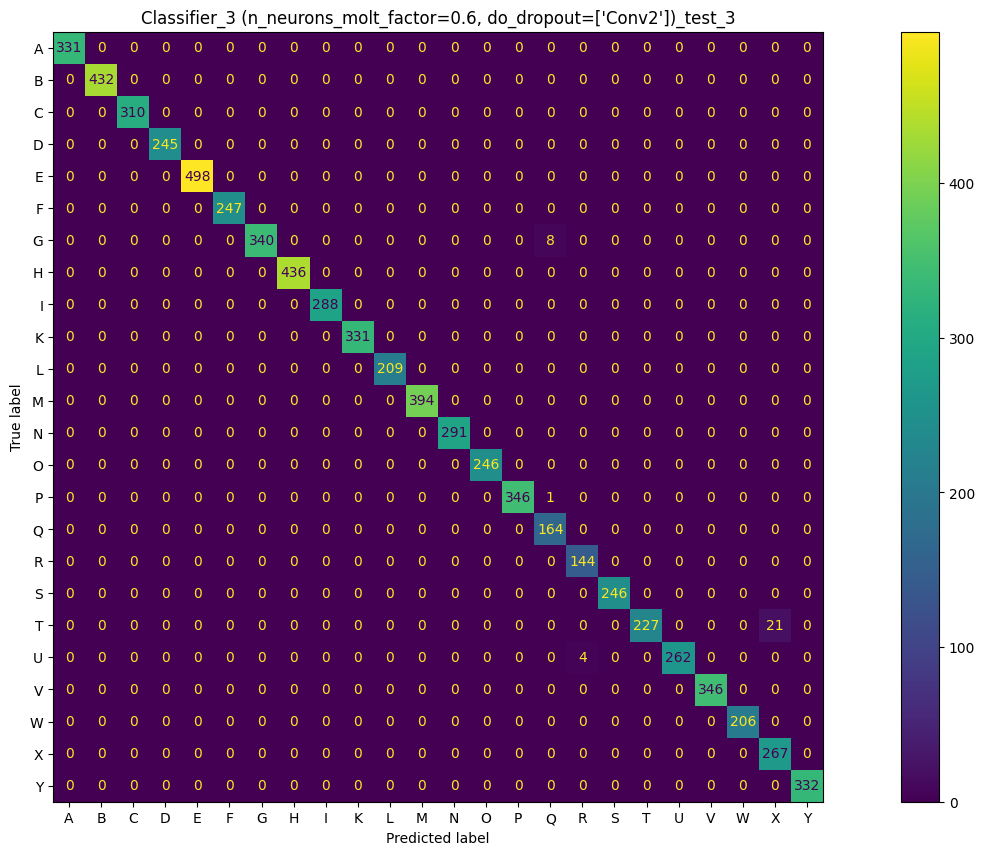

WRONG PREDICTIONS:


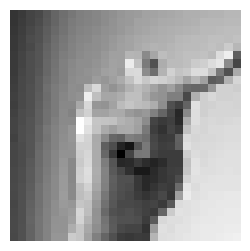

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 1e-04,
 'D': 0.0043,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0297,
 'H': 0.0003,
 'I': 1e-04,
 'K': 0.0006,
 'L': 0.0039,
 'M': 0.0,
 'N': 0.0007,
 'O': 0.0,
 'P': 1e-04,
 'Q': 0.0,
 'R': 0.0012,
 'S': 1e-04,
 'T': 0.046,
 'U': 0.0003,
 'V': 0.0003,
 'W': 0.0,
 'X': 0.9119,
 'Y': 0.0003}

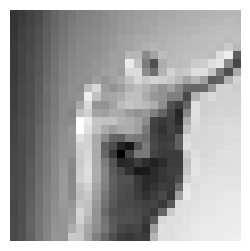

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 1e-04,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0115,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0004,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 1e-04,
 'S': 0.0,
 'T': 0.0465,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9412,
 'Y': 0.0}

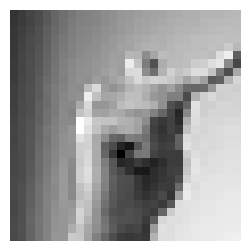

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0004,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0147,
 'H': 1e-04,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0008,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0002,
 'S': 0.0,
 'T': 0.0495,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9342,
 'Y': 0.0}

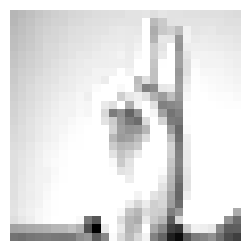

true response: U
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.5352,
 'S': 0.0,
 'T': 0.0,
 'U': 0.4648,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

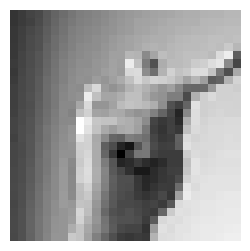

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.001,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0142,
 'H': 1e-04,
 'I': 0.0,
 'K': 1e-04,
 'L': 0.0011,
 'M': 0.0,
 'N': 1e-04,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0003,
 'S': 0.0,
 'T': 0.0399,
 'U': 0.0,
 'V': 1e-04,
 'W': 0.0,
 'X': 0.9431,
 'Y': 0.0}

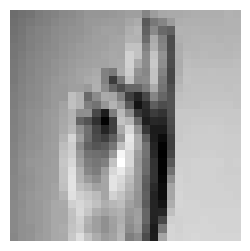

true response: U
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0092,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.5368,
 'S': 0.0,
 'T': 0.0,
 'U': 0.451,
 'V': 0.0029,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

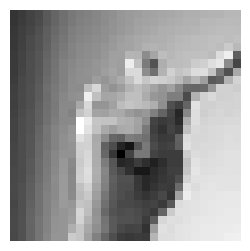

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 1e-04,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0061,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0002,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0273,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9663,
 'Y': 0.0}

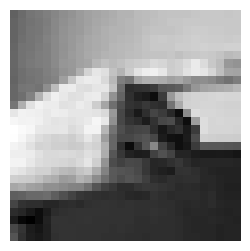

true response: G
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.4816,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 1e-04,
 'Q': 0.5175,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0008,
 'Y': 0.0}

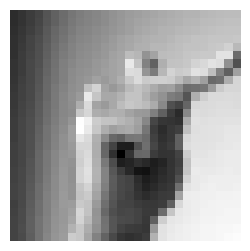

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0002,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0077,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 1e-04,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0212,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9708,
 'Y': 0.0}

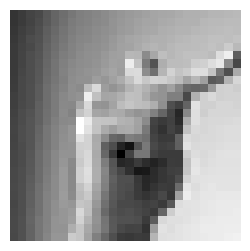

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 1e-04,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0116,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0004,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 1e-04,
 'S': 0.0,
 'T': 0.0496,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9381,
 'Y': 0.0}

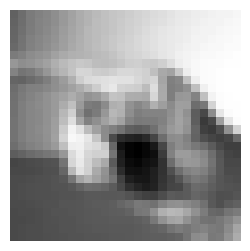

true response: P
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0009,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.3231,
 'Q': 0.6759,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

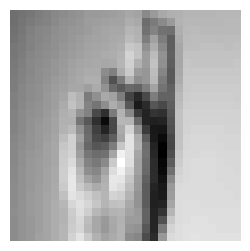

true response: U
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0265,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.6929,
 'S': 1e-04,
 'T': 0.0,
 'U': 0.2733,
 'V': 0.0071,
 'W': 1e-04,
 'X': 0.0,
 'Y': 0.0}

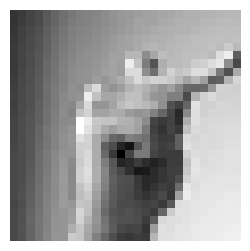

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 1e-04,
 'D': 0.0039,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0296,
 'H': 0.0003,
 'I': 1e-04,
 'K': 0.0006,
 'L': 0.0035,
 'M': 0.0,
 'N': 0.0007,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.001,
 'S': 1e-04,
 'T': 0.0412,
 'U': 0.0002,
 'V': 0.0003,
 'W': 0.0,
 'X': 0.9183,
 'Y': 0.0002}

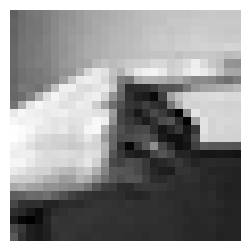

true response: G
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.3235,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.6763,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0002,
 'Y': 0.0}

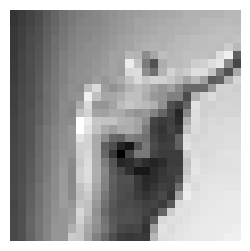

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 1e-04,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0096,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0003,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 1e-04,
 'S': 0.0,
 'T': 0.0429,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9469,
 'Y': 0.0}

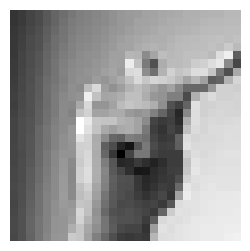

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0002,
 'E': 0.0,
 'F': 0.0,
 'G': 0.012,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0005,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 1e-04,
 'S': 0.0,
 'T': 0.0461,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.941,
 'Y': 0.0}

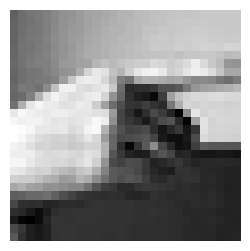

true response: G
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.4435,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.5553,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0012,
 'Y': 0.0}

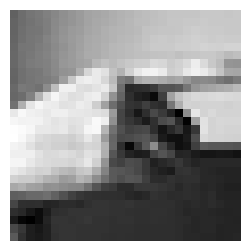

true response: G
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.4808,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.519,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0002,
 'Y': 0.0}

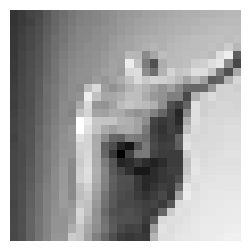

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0002,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0054,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0002,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.02,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9741,
 'Y': 0.0}

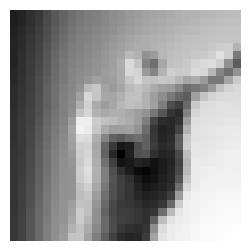

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0003,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0086,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 1e-04,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 1e-04,
 'S': 0.0,
 'T': 0.019,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9718,
 'Y': 0.0}

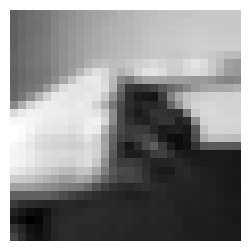

true response: G
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.2214,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 1e-04,
 'Q': 0.7771,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0013,
 'Y': 0.0}

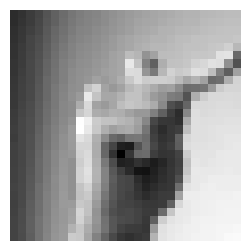

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0002,
 'E': 0.0,
 'F': 0.0,
 'G': 0.008,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 1e-04,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0204,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9712,
 'Y': 0.0}

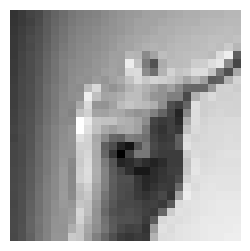

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0005,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0126,
 'H': 1e-04,
 'I': 0.0,
 'K': 1e-04,
 'L': 0.0008,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0002,
 'S': 0.0,
 'T': 0.0427,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9429,
 'Y': 0.0}

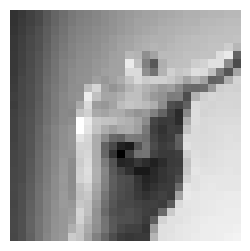

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 1e-04,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0082,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0002,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0233,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9682,
 'Y': 0.0}

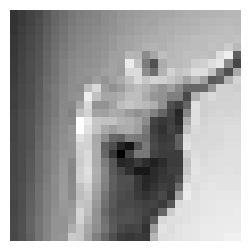

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0002,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0084,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0004,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 1e-04,
 'S': 0.0,
 'T': 0.0309,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.96,
 'Y': 0.0}

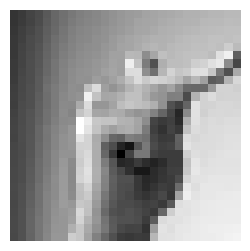

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0017,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0099,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9884,
 'Y': 0.0}

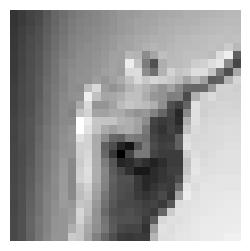

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0011,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0155,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9835,
 'Y': 0.0}

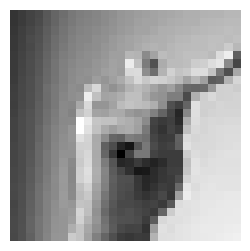

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0024,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0133,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9843,
 'Y': 0.0}

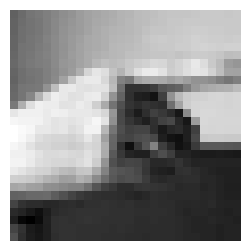

true response: G
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.3836,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 1e-04,
 'Q': 0.6154,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0009,
 'Y': 0.0}

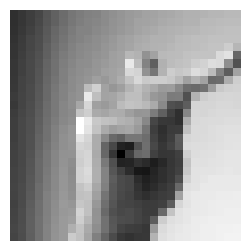

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0002,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0086,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0002,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0227,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9683,
 'Y': 0.0}

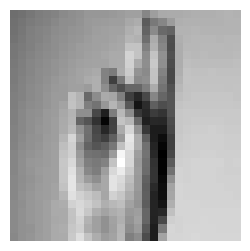

true response: U
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0099,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.5574,
 'S': 0.0,
 'T': 0.0,
 'U': 0.4294,
 'V': 0.0032,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

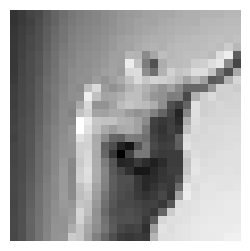

true response: T
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 1e-04,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0052,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0002,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0207,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9738,
 'Y': 0.0}

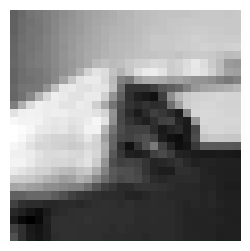

true response: G
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.3112,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 1e-04,
 'Q': 0.6878,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0009,
 'Y': 0.0}

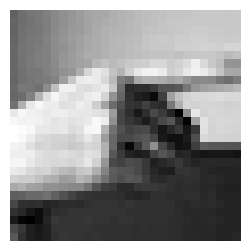

true response: G
predicted:


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.3963,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.6029,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0007,
 'Y': 0.0}

In [30]:
best_model = NeuralNetwork.load_NN(all_results.iloc[3], classifiers_dict, torch.device("cuda"), (28,28))
best_model.explore_wrong_predictions()

In [22]:
best_model.return_stats()

,epochs,train_losses,eval_losses,test_accuracies,training_time_per_epoch
0,1,0.077401,2.610158e-02,0.691718,0.947430
1,2,0.019288,4.360401e-03,0.894869,0.769467
2,3,0.007694,8.499454e-04,0.951199,0.767720
3,4,0.004738,4.937100e-04,0.960820,0.765589
4,5,0.002783,3.412030e-04,0.953709,0.766958
5,6,0.002204,4.696845e-05,0.973787,0.767695
6,7,0.001949,7.173570e-05,0.969325,0.767806
7,8,0.001484,3.575289e-05,0.961517,0.765984
8,9,0.001310,4.563843e-05,0.965003,0.764533
9,10,0.001067,4.481728e-05,0.970162,0.770225


In [23]:
all_results.sort_values(by=['test_accuracies'], ascending=True).head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
1,1,0,0.6,['Conv2'],0.0005,32,5,0.25,0.972253,0.091232,7.001711
0,0,0,0.6,['Conv2'],0.0005,32,5,0.00,0.981735,0.080683,30.840531
6,6,0,0.6,['Conv2'],0.0005,32,10,0.50,0.987451,0.082619,55.975638
2,2,0,0.6,['Conv2'],0.0005,32,5,0.50,0.987591,0.080886,14.667440
7,7,0,0.6,['Conv2'],0.0005,32,10,0.75,0.993028,0.081127,26.303567
4,4,0,0.6,['Conv2'],0.0005,32,10,0.00,0.994283,0.081447,30.537555
5,5,0,0.6,['Conv2'],0.0005,32,10,0.25,0.994980,0.081631,42.559637
3,3,0,0.6,['Conv2'],0.0005,32,5,0.75,0.995259,0.080821,10.189537


In [24]:
n_low_accuracy_architectures = len(all_results[all_results["test_accuracies"]==all_results["test_accuracies"].min()])
n_low_accuracy_architectures

1

In [25]:
all_results.sort_values(by=['test_accuracies'], ascending=True).head(n_low_accuracy_architectures)["architecture_id"].unique()

array([0])

In [26]:
architecture_stats(all_results, classifiers_dict, 0)

Stats for architecture: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2']) (id: 0)
mean accuracy: 0.9883 with standard error: 0.0080

worst accuracy: 0.9723 with hyperparameters:
test_id                          1
lr                          0.0005
batch_size                      32
patience                         5
data_augmentation_perc        0.25
test_times                0.091232
train_times               7.001711
Name: 1, dtype: object 

best accuracy: 0.9953 with hyperparameters:
test_id                           3
lr                           0.0005
batch_size                       32
patience                          5
data_augmentation_perc         0.75
test_times                 0.080821
train_times               10.189537
Name: 3, dtype: object 



Loaded model: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2'])_test_0


Architecture:
name: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2'])
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 32, 12, 12]          --
|    └─Conv2d: 2-1                       [-1, 32, 24, 24]          832
|    └─MaxPool2d: 2-2                    [-1, 32, 12, 12]          --
|    └─ReLU: 2-3                         [-1, 32, 12, 12]          --
├─Sequential: 1-2                        [-1, 64, 4, 4]            --
|    └─Conv2d: 2-4                       [-1, 64, 8, 8]            51,264
|    └─MaxPool2d: 2-5                    [-1, 64, 4, 4]            --
|    └─ReLU: 2-6                         [-1, 64, 4, 4]            --
|    └─Dropout: 2-7                      [-1, 64, 4, 4]            --
├─Sequential: 1-3                        [-1, 128, 1, 1]           --
|    └─Conv2d: 2-8                       [-1, 128, 

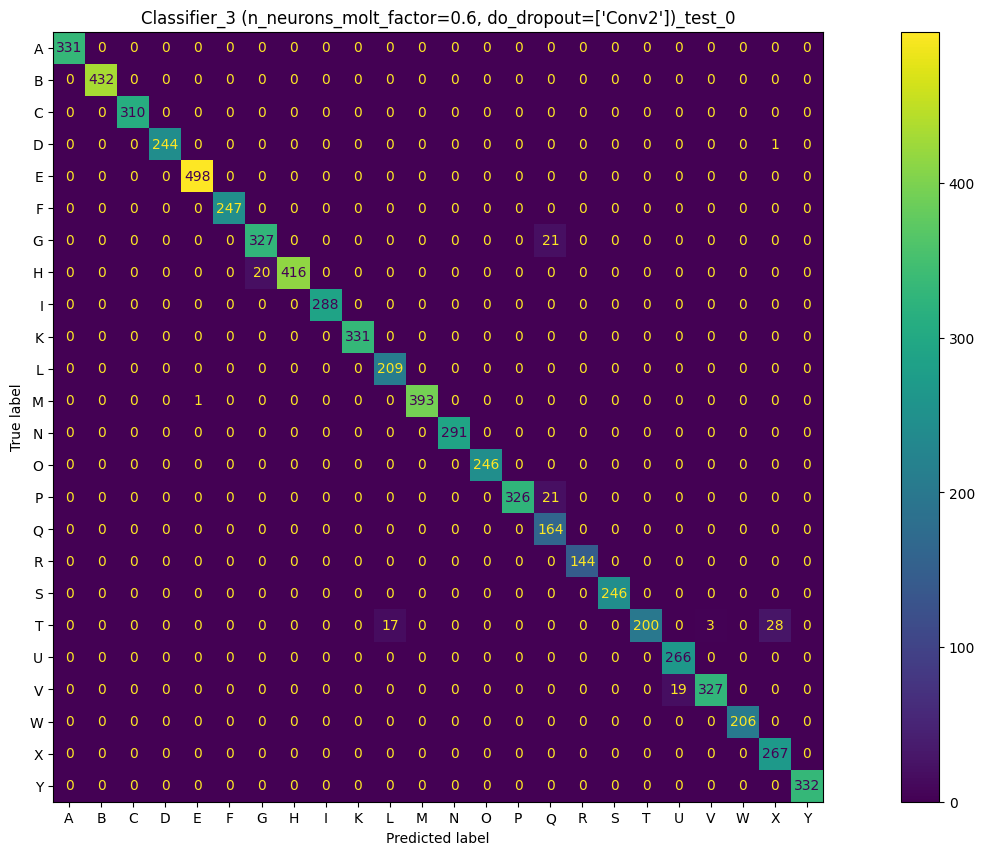

In [27]:
NeuralNetwork.load_NN(all_results.iloc[0], classifiers_dict, torch.device("cuda"), (28,28)).plot_confusion_matrix()

In [28]:
all_results.sort_values(by=['test_accuracies'], ascending=True).iloc[320:330]

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times


In [29]:
model = NeuralNetwork.load_NN(all_results.iloc[2880], classifiers_dict, torch.device("cuda"), (28,28))
model.plot_confusion_matrix()

IndexError: single positional indexer is out-of-bounds

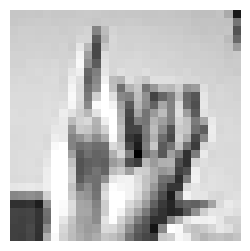

True label: I


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 1.0,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

In [ ]:
image, response = sample_image(index = 10)
best_model.predict(image)